## Graph Neural Network Models for logS Prediction

The aqueous-solubility prediction workflow was implemented using graph neural
networks (GNNs). Molecular structures were converted from SMILES into molecular
graphs, where atoms were represented as nodes and covalent bonds as edges.
The same graph representation was used for both model architectures. :contentReference[oaicite:0]{index=0}

Two GNN architectures were implemented and evaluated:

- **Graph Convolutional Network (GCN)**
- **Graph Attention Network (GAT)**

Both models were designed for **graph-level regression**, with experimental
logS as the continuous prediction target. :contentReference[oaicite:1]{index=1} :contentReference[oaicite:2]{index=2}

### Molecular Graph Representation

Each molecule was converted into a PyTorch Geometric graph:

- atoms were represented as graph nodes;
- covalent bonds were represented as bidirectional graph edges;
- experimental logS was used as the graph-level regression target. :contentReference[oaicite:3]{index=3}

Atom features included:

- element identity;
- atomic degree;
- formal charge;
- hybridization;
- number of attached hydrogens;
- aromaticity;
- ring membership;
- scaled atomic mass. :contentReference[oaicite:4]{index=4}

### Model Comparison

Four experiments were performed:

1. GCN with a random split
2. GAT with a random split
3. GCN with a Bemis--Murcko scaffold split
4. GAT with a Bemis--Murcko scaffold split :contentReference[oaicite:5]{index=5}

The same preprocessing and graph representation were used across the
experiments to provide a consistent comparison between architectures and
splitting strategies. :contentReference[oaicite:6]{index=6}

### Training and Evaluation

The models were trained as regression models using mean squared error (MSE)
loss. Validation RMSE was used for model monitoring and early stopping, and
performance was reported using RMSE, MAE, and coefficient of determination
($R^2$) on the original logS scale. :contentReference[oaicite:7]{index=7}
:contentReference[oaicite:8]{index=8}

The scaffold-based GCN was ultimately retained as the logS prediction model
used in the REINVENT reward workflow.

## GCN and GAT Model Performance

| Experiment | Model | Split | Best Epoch | Validation RMSE | Validation MAE | Validation R² | Test RMSE | Test MAE | Test R² |
|---|---|---|---:|---:|---:|---:|---:|---:|---:|
| GAT Random | GAT | Random | 66 | 0.959 | 0.704 | 0.838 | 1.070 | 0.736 | 0.787 |
| GAT Scaffold | GAT | Scaffold | 60 | 1.115 | 0.772 | 0.792 | 1.121 | 0.791 | 0.776 |
| GCN Random | GCN | Random | 93 | 0.903 | 0.655 | 0.856 | 0.980 | 0.662 | 0.821 |
| GCN Scaffold | GCN | Scaffold | 154 | 1.057 | 0.715 | 0.813 | 1.095 | 0.751 | 0.786 |

The GCN architecture showed stronger overall predictive performance than the
corresponding GAT models. The random-split GCN achieved the highest numerical
performance, with a test R² of 0.821 and RMSE of 0.980.

For downstream logS prediction, the scaffold-based GCN was retained because
scaffold splitting provides a more stringent assessment of generalization to
structurally distinct molecules. The scaffold-based GCN achieved a test R² of
0.786, RMSE of 1.095, and MAE of 0.751.

In [ ]:
# ============================================================
# TRAIN GCN OR GAT FOR AQSOLDB SOLUBILITY PREDICTION
#
# This script:
# 1. Loads random-split or scaffold-split AqSolDB CSV files
# 2. Converts every molecular SMILES into a graph
# 3. Represents atoms as graph nodes and bonds as graph edges
# 4. Creates identical graph inputs for GCN and GAT
# 5. Standardizes logS using training-set statistics only
# 6. Trains either a GCN or GAT regression model
# 7. Uses validation RMSE for early stopping
# 8. Restores the best model checkpoint
# 9. Evaluates the model on train, validation, and test sets
# 10. Saves model weights, metrics, history, and predictions
#
# Important:
# - Use the same preprocessing for every experiment.
# - Use the same hyperparameters for GCN and GAT initially.
# - Random and scaffold splits are loaded from separate files.
# - Target normalization is calculated using the training set only.
# - Report metrics in the original logS scale.
#
# Four experiments:
# 1. GCN with random split
# 2. GAT with random split
# 3. GCN with scaffold split
# 4. GAT with scaffold split
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from __future__ import annotations

from pathlib import Path
import argparse
import json
import math
import random
from typing import Dict, List, Sequence, Tuple

import numpy as np
import pandas as pd

import torch
from torch import nn
import torch.nn.functional as F

from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem.rdchem import Atom, HybridizationType

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GATConv,
    GCNConv,
    global_mean_pool,
)


# ============================================================
# 2. COMMAND-LINE ARGUMENTS
# ============================================================

def parse_arguments() -> argparse.Namespace:
    """
    Read the model and split choices from the command line.

    Examples
    --------
    python src/models/train_gnn.py --model gcn --split random

    python src/models/train_gnn.py --model gat --split scaffold
    """

    parser = argparse.ArgumentParser(
        description=(
            "Train a GCN or GAT model for AqSolDB "
            "solubility prediction."
        )
    )

    parser.add_argument(
        "--model",
        choices=["gcn", "gat"],
        required=True,
        help="Graph-neural-network architecture.",
    )

    parser.add_argument(
        "--split",
        choices=["random", "scaffold"],
        required=True,
        help="Dataset split strategy.",
    )

    parser.add_argument(
        "--epochs",
        type=int,
        default=300,
        help="Maximum number of training epochs.",
    )

    parser.add_argument(
        "--batch-size",
        type=int,
        default=64,
        help="Number of molecular graphs per batch.",
    )

    parser.add_argument(
        "--hidden-dim",
        type=int,
        default=128,
        help="Hidden representation size.",
    )

    parser.add_argument(
        "--num-layers",
        type=int,
        default=3,
        help="Number of graph message-passing layers.",
    )

    parser.add_argument(
        "--dropout",
        type=float,
        default=0.20,
        help="Dropout probability.",
    )

    parser.add_argument(
        "--learning-rate",
        type=float,
        default=1.0e-3,
        help="Initial learning rate.",
    )

    parser.add_argument(
        "--weight-decay",
        type=float,
        default=1.0e-5,
        help="AdamW weight-decay coefficient.",
    )

    parser.add_argument(
        "--patience",
        type=int,
        default=40,
        help="Early-stopping patience in epochs.",
    )

    parser.add_argument(
        "--seed",
        type=int,
        default=42,
        help="Random seed.",
    )

    parser.add_argument(
        "--num-workers",
        type=int,
        default=0,
        help=(
            "DataLoader worker count. Keep this at zero "
            "initially on macOS."
        ),
    )

    return parser.parse_args()


# ============================================================
# 3. REPRODUCIBILITY
# ============================================================

def set_random_seed(seed: int) -> None:
    """
    Set Python, NumPy, and PyTorch random seeds.
    """

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # These settings improve repeatability on CUDA.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ============================================================
# 4. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path(__file__).resolve().parents[2]

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

MODEL_OUTPUT_ROOT = (
    PROJECT_ROOT
    / "outputs"
    / "gnn_experiments"
)


# ============================================================
# 5. ATOM-FEATURE CONFIGURATION
# ============================================================

# These elements match the cleaned AqSolDB element filter.
ATOM_SYMBOLS = [
    "C",
    "N",
    "O",
    "S",
    "P",
    "F",
    "Cl",
    "Br",
    "I",
    "B",
    "Si",
]


DEGREE_VALUES = [
    0,
    1,
    2,
    3,
    4,
    5,
]


FORMAL_CHARGE_VALUES = [
    -2,
    -1,
    0,
    1,
    2,
]


HYBRIDIZATION_VALUES = [
    HybridizationType.SP,
    HybridizationType.SP2,
    HybridizationType.SP3,
    HybridizationType.SP3D,
    HybridizationType.SP3D2,
]


TOTAL_H_VALUES = [
    0,
    1,
    2,
    3,
    4,
]


# ============================================================
# 6. FEATURE-ENCODING HELPERS
# ============================================================

def one_hot_with_unknown(
    value,
    allowed_values: Sequence,
) -> List[float]:
    """
    One-hot encode a value and reserve the final position
    for unknown or unexpected values.
    """

    encoding = [
        0.0
        for _ in range(
            len(allowed_values) + 1
        )
    ]

    try:
        index = allowed_values.index(value)

    except ValueError:
        index = len(allowed_values)

    encoding[index] = 1.0

    return encoding


def atom_to_features(atom: Atom) -> List[float]:
    """
    Convert one RDKit atom into a numerical feature vector.

    Features
    --------
    - Element identity
    - Atom degree
    - Formal charge
    - Hybridization
    - Number of attached hydrogens
    - Aromaticity
    - Ring membership
    - Scaled atomic mass
    """

    features: List[float] = []

    features.extend(
        one_hot_with_unknown(
            atom.GetSymbol(),
            ATOM_SYMBOLS,
        )
    )

    features.extend(
        one_hot_with_unknown(
            atom.GetDegree(),
            DEGREE_VALUES,
        )
    )

    features.extend(
        one_hot_with_unknown(
            atom.GetFormalCharge(),
            FORMAL_CHARGE_VALUES,
        )
    )

    features.extend(
        one_hot_with_unknown(
            atom.GetHybridization(),
            HYBRIDIZATION_VALUES,
        )
    )

    features.extend(
        one_hot_with_unknown(
            atom.GetTotalNumHs(),
            TOTAL_H_VALUES,
        )
    )

    features.append(
        float(atom.GetIsAromatic())
    )

    features.append(
        float(atom.IsInRing())
    )

    # Scaling keeps atomic mass numerically moderate.
    features.append(
        atom.GetMass() / 100.0
    )

    return features


# Calculate the atom-feature dimension once.
EXAMPLE_ATOM = Chem.MolFromSmiles("C").GetAtomWithIdx(0)

NODE_FEATURE_DIM = len(
    atom_to_features(EXAMPLE_ATOM)
)


# ============================================================
# 7. CONVERT SMILES TO GRAPH
# ============================================================

def smiles_to_graph(
    smiles: str,
    target: float,
    row_index: int,
) -> Data:
    """
    Convert one molecule into a PyTorch Geometric graph.

    Nodes
    -----
    Molecular atoms.

    Edges
    -----
    Covalent bonds. Each bond is represented in both directions.

    Target
    ------
    Experimental logS value.
    """

    molecule = Chem.MolFromSmiles(
        smiles
    )

    if molecule is None:
        raise ValueError(
            f"Invalid SMILES at row {row_index}: {smiles}"
        )

    node_features = [
        atom_to_features(atom)
        for atom in molecule.GetAtoms()
    ]

    if not node_features:
        raise ValueError(
            f"Molecule contains no atoms at row {row_index}: "
            f"{smiles}"
        )

    x = torch.tensor(
        node_features,
        dtype=torch.float32,
    )

    source_nodes: List[int] = []
    destination_nodes: List[int] = []

    for bond in molecule.GetBonds():
        begin_index = bond.GetBeginAtomIdx()
        end_index = bond.GetEndAtomIdx()

        # Molecular bonds are represented as directed edges
        # in both directions.
        source_nodes.extend(
            [
                begin_index,
                end_index,
            ]
        )

        destination_nodes.extend(
            [
                end_index,
                begin_index,
            ]
        )

    # Some valid structures may contain one atom and no bonds.
    # PyTorch Geometric accepts an empty edge tensor.
    if source_nodes:
        edge_index = torch.tensor(
            [
                source_nodes,
                destination_nodes,
            ],
            dtype=torch.long,
        )

    else:
        edge_index = torch.empty(
            (
                2,
                0,
            ),
            dtype=torch.long,
        )

    y = torch.tensor(
        [
            float(target)
        ],
        dtype=torch.float32,
    )

    graph = Data(
        x=x,
        edge_index=edge_index,
        y=y,
    )

    # Store metadata for prediction files.
    graph.smiles = smiles
    graph.row_index = int(row_index)

    return graph


def dataframe_to_graphs(
    dataframe: pd.DataFrame,
    dataset_name: str,
) -> List[Data]:
    """
    Convert an entire dataframe into molecular graphs.
    """

    graphs: List[Data] = []

    print(
        f"\nConverting {dataset_name} molecules to graphs..."
    )

    for row_index, row in dataframe.reset_index(
        drop=True
    ).iterrows():

        graph = smiles_to_graph(
            smiles=str(row["smiles"]),
            target=float(row["logS"]),
            row_index=row_index,
        )

        graphs.append(graph)

    print(
        f"Created {len(graphs):,} graphs for {dataset_name}."
    )

    return graphs


# ============================================================
# 8. LOAD THE REQUESTED DATA SPLIT
# ============================================================

def get_split_paths(
    split_name: str,
) -> Tuple[Path, Path, Path]:
    """
    Return train, validation, and test file paths.
    """

    if split_name == "random":
        return (
            PROCESSED_DIR / "aqsoldb_train.csv",
            PROCESSED_DIR / "aqsoldb_validation.csv",
            PROCESSED_DIR / "aqsoldb_test.csv",
        )

    if split_name == "scaffold":
        return (
            PROCESSED_DIR / "aqsoldb_scaffold_train.csv",
            PROCESSED_DIR / "aqsoldb_scaffold_validation.csv",
            PROCESSED_DIR / "aqsoldb_scaffold_test.csv",
        )

    raise ValueError(
        f"Unsupported split name: {split_name}"
    )


def load_split_dataframe(
    path: Path,
    dataset_name: str,
) -> pd.DataFrame:
    """
    Load and validate one split CSV file.
    """

    if not path.exists():
        raise FileNotFoundError(
            f"{dataset_name} file was not found:\n{path}"
        )

    dataframe = pd.read_csv(
        path
    )

    required_columns = {
        "smiles",
        "logS",
    }

    missing_columns = required_columns.difference(
        dataframe.columns
    )

    if missing_columns:
        raise ValueError(
            f"{dataset_name} is missing columns: "
            f"{sorted(missing_columns)}"
        )

    if dataframe["smiles"].isna().any():
        raise ValueError(
            f"{dataset_name} contains missing SMILES."
        )

    if dataframe["logS"].isna().any():
        raise ValueError(
            f"{dataset_name} contains missing targets."
        )

    if not np.isfinite(
        dataframe["logS"]
    ).all():
        raise ValueError(
            f"{dataset_name} contains nonfinite targets."
        )

    if dataframe["smiles"].duplicated().any():
        raise ValueError(
            f"{dataset_name} contains duplicate SMILES."
        )

    return dataframe.reset_index(
        drop=True
    )


# ============================================================
# 9. VERIFY SPLIT OVERLAP
# ============================================================

def verify_no_smiles_overlap(
    train_df: pd.DataFrame,
    validation_df: pd.DataFrame,
    test_df: pd.DataFrame,
) -> None:
    """
    Confirm that no molecular SMILES appears in two splits.
    """

    train_smiles = set(
        train_df["smiles"]
    )

    validation_smiles = set(
        validation_df["smiles"]
    )

    test_smiles = set(
        test_df["smiles"]
    )

    train_validation_overlap = (
        train_smiles
        & validation_smiles
    )

    train_test_overlap = (
        train_smiles
        & test_smiles
    )

    validation_test_overlap = (
        validation_smiles
        & test_smiles
    )

    if train_validation_overlap:
        raise ValueError(
            "Train and validation SMILES overlap."
        )

    if train_test_overlap:
        raise ValueError(
            "Train and test SMILES overlap."
        )

    if validation_test_overlap:
        raise ValueError(
            "Validation and test SMILES overlap."
        )


# ============================================================
# 10. TARGET NORMALIZATION
# ============================================================

def normalize_graph_targets(
    graphs: List[Data],
    target_mean: float,
    target_std: float,
) -> None:
    """
    Normalize graph targets in place using training statistics.
    """

    for graph in graphs:
        graph.y = (
            graph.y - target_mean
        ) / target_std


# ============================================================
# 11. GCN MODEL
# ============================================================

class GCNRegressor(nn.Module):
    """
    Graph convolutional network for graph-level regression.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
    ) -> None:
        super().__init__()

        if num_layers < 1:
            raise ValueError(
                "num_layers must be at least one."
            )

        self.dropout = dropout

        self.convolutions = nn.ModuleList()
        self.normalizations = nn.ModuleList()

        self.convolutions.append(
            GCNConv(
                input_dim,
                hidden_dim,
            )
        )

        self.normalizations.append(
            nn.BatchNorm1d(
                hidden_dim
            )
        )

        for _ in range(
            num_layers - 1
        ):
            self.convolutions.append(
                GCNConv(
                    hidden_dim,
                    hidden_dim,
                )
            )

            self.normalizations.append(
                nn.BatchNorm1d(
                    hidden_dim
                )
            )

        self.regression_head = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
            nn.ReLU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden_dim,
                1,
            ),
        )

    def forward(
        self,
        data: Data,
    ) -> torch.Tensor:

        x = data.x
        edge_index = data.edge_index
        batch = data.batch

        for convolution, normalization in zip(
            self.convolutions,
            self.normalizations,
        ):
            x = convolution(
                x,
                edge_index,
            )

            x = normalization(
                x
            )

            x = F.relu(
                x
            )

            x = F.dropout(
                x,
                p=self.dropout,
                training=self.training,
            )

        graph_embedding = global_mean_pool(
            x,
            batch,
        )

        prediction = self.regression_head(
            graph_embedding
        )

        return prediction.view(-1)


# ============================================================
# 12. GAT MODEL
# ============================================================

class GATRegressor(nn.Module):
    """
    Graph attention network for graph-level regression.
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
        heads: int = 4,
    ) -> None:
        super().__init__()

        if num_layers < 1:
            raise ValueError(
                "num_layers must be at least one."
            )

        if hidden_dim % heads != 0:
            raise ValueError(
                "hidden_dim must be divisible by heads."
            )

        self.dropout = dropout
        self.heads = heads

        per_head_dimension = (
            hidden_dim // heads
        )

        self.convolutions = nn.ModuleList()
        self.normalizations = nn.ModuleList()

        self.convolutions.append(
            GATConv(
                input_dim,
                per_head_dimension,
                heads=heads,
                concat=True,
                dropout=dropout,
            )
        )

        self.normalizations.append(
            nn.BatchNorm1d(
                hidden_dim
            )
        )

        for _ in range(
            num_layers - 1
        ):
            self.convolutions.append(
                GATConv(
                    hidden_dim,
                    per_head_dimension,
                    heads=heads,
                    concat=True,
                    dropout=dropout,
                )
            )

            self.normalizations.append(
                nn.BatchNorm1d(
                    hidden_dim
                )
            )

        self.regression_head = nn.Sequential(
            nn.Linear(
                hidden_dim,
                hidden_dim,
            ),
            nn.ReLU(),
            nn.Dropout(
                dropout
            ),
            nn.Linear(
                hidden_dim,
                1,
            ),
        )

    def forward(
        self,
        data: Data,
    ) -> torch.Tensor:

        x = data.x
        edge_index = data.edge_index
        batch = data.batch

        for convolution, normalization in zip(
            self.convolutions,
            self.normalizations,
        ):
            x = convolution(
                x,
                edge_index,
            )

            x = normalization(
                x
            )

            x = F.elu(
                x
            )

            x = F.dropout(
                x,
                p=self.dropout,
                training=self.training,
            )

        graph_embedding = global_mean_pool(
            x,
            batch,
        )

        prediction = self.regression_head(
            graph_embedding
        )

        return prediction.view(-1)


# ============================================================
# 13. MODEL FACTORY
# ============================================================

def create_model(
    model_name: str,
    input_dim: int,
    hidden_dim: int,
    num_layers: int,
    dropout: float,
) -> nn.Module:
    """
    Create the requested model architecture.
    """

    if model_name == "gcn":
        return GCNRegressor(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
        )

    if model_name == "gat":
        return GATRegressor(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            num_layers=num_layers,
            dropout=dropout,
            heads=4,
        )

    raise ValueError(
        f"Unsupported model: {model_name}"
    )


# ============================================================
# 14. REGRESSION METRICS
# ============================================================

def calculate_metrics(
    targets: np.ndarray,
    predictions: np.ndarray,
) -> Dict[str, float]:
    """
    Calculate RMSE, MAE, and coefficient of determination.
    """

    targets = np.asarray(
        targets,
        dtype=np.float64,
    )

    predictions = np.asarray(
        predictions,
        dtype=np.float64,
    )

    if targets.shape != predictions.shape:
        raise ValueError(
            "Targets and predictions have different shapes."
        )

    residuals = (
        predictions - targets
    )

    mse = float(
        np.mean(
            residuals ** 2
        )
    )

    rmse = float(
        math.sqrt(mse)
    )

    mae = float(
        np.mean(
            np.abs(
                residuals
            )
        )
    )

    total_sum_of_squares = float(
        np.sum(
            (
                targets
                - np.mean(targets)
            )
            ** 2
        )
    )

    residual_sum_of_squares = float(
        np.sum(
            residuals ** 2
        )
    )

    if total_sum_of_squares == 0:
        r2 = float("nan")

    else:
        r2 = float(
            1.0
            - residual_sum_of_squares
            / total_sum_of_squares
        )

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }


# ============================================================
# 15. TRAIN FOR ONE EPOCH
# ============================================================

def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> float:
    """
    Train the model for one epoch using normalized targets.
    """

    model.train()

    total_squared_error = 0.0
    total_examples = 0

    for batch in loader:
        batch = batch.to(
            device
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        predictions = model(
            batch
        )

        targets = batch.y.view(-1)

        loss = F.mse_loss(
            predictions,
            targets,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        batch_size = int(
            targets.numel()
        )

        total_squared_error += (
            float(loss.item())
            * batch_size
        )

        total_examples += batch_size

    if total_examples == 0:
        raise ValueError(
            "The training loader produced no examples."
        )

    return (
        total_squared_error
        / total_examples
    )


# ============================================================
# 16. PREDICTION AND EVALUATION
# ============================================================

@torch.no_grad()
def predict(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    target_mean: float,
    target_std: float,
) -> Tuple[np.ndarray, np.ndarray, List[str]]:
    """
    Predict logS and convert values back to the original scale.
    """

    model.eval()

    normalized_targets: List[float] = []
    normalized_predictions: List[float] = []
    smiles_values: List[str] = []

    for batch in loader:
        batch = batch.to(
            device
        )

        batch_predictions = model(
            batch
        )

        batch_targets = batch.y.view(-1)

        normalized_predictions.extend(
            batch_predictions
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        normalized_targets.extend(
            batch_targets
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

        # PyG batches string attributes into a Python list.
        batch_smiles = batch.smiles

        if isinstance(
            batch_smiles,
            str,
        ):
            smiles_values.append(
                batch_smiles
            )

        else:
            smiles_values.extend(
                list(batch_smiles)
            )

    normalized_targets_array = np.asarray(
        normalized_targets,
        dtype=np.float64,
    )

    normalized_predictions_array = np.asarray(
        normalized_predictions,
        dtype=np.float64,
    )

    targets = (
        normalized_targets_array
        * target_std
        + target_mean
    )

    predictions = (
        normalized_predictions_array
        * target_std
        + target_mean
    )

    return (
        targets,
        predictions,
        smiles_values,
    )


def evaluate(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    target_mean: float,
    target_std: float,
) -> Tuple[
    Dict[str, float],
    np.ndarray,
    np.ndarray,
    List[str],
]:
    """
    Evaluate a model in the original logS scale.
    """

    targets, predictions, smiles_values = predict(
        model=model,
        loader=loader,
        device=device,
        target_mean=target_mean,
        target_std=target_std,
    )

    metrics = calculate_metrics(
        targets=targets,
        predictions=predictions,
    )

    return (
        metrics,
        targets,
        predictions,
        smiles_values,
    )


# ============================================================
# 17. SAVE PREDICTIONS
# ============================================================

def save_predictions(
    output_path: Path,
    smiles_values: List[str],
    targets: np.ndarray,
    predictions: np.ndarray,
) -> None:
    """
    Save observed and predicted logS values.
    """

    prediction_df = pd.DataFrame(
        {
            "smiles": smiles_values,
            "observed_logS": targets,
            "predicted_logS": predictions,
            "residual": predictions - targets,
            "absolute_error": np.abs(
                predictions - targets
            ),
        }
    )

    prediction_df.to_csv(
        output_path,
        index=False,
    )


# ============================================================
# 18. MAIN TRAINING WORKFLOW
# ============================================================

def main() -> None:
    """
    Run one model-and-split experiment.
    """

    arguments = parse_arguments()

    set_random_seed(
        arguments.seed
    )

    RDLogger.DisableLog(
        "rdApp.*"
    )

    experiment_name = (
        f"{arguments.model}_{arguments.split}"
    )

    output_dir = (
        MODEL_OUTPUT_ROOT
        / experiment_name
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    print("\nExperiment configuration")
    print("=" * 70)

    print(
        "Experiment:",
        experiment_name,
    )

    print(
        "Model:",
        arguments.model.upper(),
    )

    print(
        "Split:",
        arguments.split,
    )

    print(
        "Random seed:",
        arguments.seed,
    )

    print(
        "Node feature dimension:",
        NODE_FEATURE_DIM,
    )

    # --------------------------------------------------------
    # Select device
    # --------------------------------------------------------

        # --------------------------------------------------------
    # Select device
    # --------------------------------------------------------

    # Use CUDA first when an NVIDIA GPU is available
    if torch.cuda.is_available():
        device = torch.device(
            "cuda"
        )

    # Force GAT to CPU on macOS
    # GATConv uses scatter operations that are not supported on MPS
    elif arguments.model == "gat":
        device = torch.device(
            "cpu"
        )

    # Use Apple MPS for GCN when available
    elif (
        hasattr(torch.backends, "mps")
        and torch.backends.mps.is_available()
    ):
        device = torch.device(
            "mps"
        )

    # Use CPU when no GPU backend is available
    else:
        device = torch.device(
            "cpu"
        )

    print(
        "Device:",
        device,
    )

    # --------------------------------------------------------
    # Load split CSV files
    # --------------------------------------------------------

    (
        train_path,
        validation_path,
        test_path,
    ) = get_split_paths(
        arguments.split
    )

    train_df = load_split_dataframe(
        train_path,
        "training dataset",
    )

    validation_df = load_split_dataframe(
        validation_path,
        "validation dataset",
    )

    test_df = load_split_dataframe(
        test_path,
        "test dataset",
    )

    verify_no_smiles_overlap(
        train_df=train_df,
        validation_df=validation_df,
        test_df=test_df,
    )

    print("\nDataset sizes")
    print("=" * 70)

    print(
        "Training:",
        len(train_df),
    )

    print(
        "Validation:",
        len(validation_df),
    )

    print(
        "Test:",
        len(test_df),
    )

    # --------------------------------------------------------
    # Calculate target normalization using training data only
    # --------------------------------------------------------

    target_mean = float(
        train_df["logS"].mean()
    )

    target_std = float(
        train_df["logS"].std(
            ddof=0
        )
    )

    if (
        not np.isfinite(target_mean)
        or not np.isfinite(target_std)
        or target_std <= 0
    ):
        raise ValueError(
            "Invalid training-target normalization statistics."
        )

    print("\nTraining-target normalization")
    print("=" * 70)

    print(
        "Training logS mean:",
        target_mean,
    )

    print(
        "Training logS standard deviation:",
        target_std,
    )

    # --------------------------------------------------------
    # Convert dataframes into graph objects
    # --------------------------------------------------------

    train_graphs = dataframe_to_graphs(
        train_df,
        "training",
    )

    validation_graphs = dataframe_to_graphs(
        validation_df,
        "validation",
    )

    test_graphs = dataframe_to_graphs(
        test_df,
        "test",
    )

    normalize_graph_targets(
        train_graphs,
        target_mean,
        target_std,
    )

    normalize_graph_targets(
        validation_graphs,
        target_mean,
        target_std,
    )

    normalize_graph_targets(
        test_graphs,
        target_mean,
        target_std,
    )

    # --------------------------------------------------------
    # Create data loaders
    # --------------------------------------------------------

    loader_generator = torch.Generator()

    loader_generator.manual_seed(
        arguments.seed
    )

    train_loader = DataLoader(
        train_graphs,
        batch_size=arguments.batch_size,
        shuffle=True,
        num_workers=arguments.num_workers,
        generator=loader_generator,
    )

    validation_loader = DataLoader(
        validation_graphs,
        batch_size=arguments.batch_size,
        shuffle=False,
        num_workers=arguments.num_workers,
    )

    test_loader = DataLoader(
        test_graphs,
        batch_size=arguments.batch_size,
        shuffle=False,
        num_workers=arguments.num_workers,
    )

    evaluation_train_loader = DataLoader(
        train_graphs,
        batch_size=arguments.batch_size,
        shuffle=False,
        num_workers=arguments.num_workers,
    )

    # --------------------------------------------------------
    # Create model
    # --------------------------------------------------------

    model = create_model(
        model_name=arguments.model,
        input_dim=NODE_FEATURE_DIM,
        hidden_dim=arguments.hidden_dim,
        num_layers=arguments.num_layers,
        dropout=arguments.dropout,
    )

    model = model.to(
        device
    )

    parameter_count = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print("\nModel")
    print("=" * 70)

    print(
        model
    )

    print(
        "Trainable parameters:",
        f"{parameter_count:,}",
    )
    # AdamW optimizer with weight decay.
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=arguments.learning_rate,
        weight_decay=arguments.weight_decay,
    )

    # Reduce the learning rate when validation performance
    # stops improving.
    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=10,
            min_lr=1.0e-6,
        )
    )

    best_model_path = (
        output_dir
        / "best_model.pt"
    )

    history_path = (
        output_dir
        / "training_history.csv"
    )

    configuration_path = (
        output_dir
        / "configuration.json"
    )

    metrics_path = (
        output_dir
        / "metrics.json"
    )

    history_records: List[
        Dict[str, float]
    ] = []

    best_validation_rmse = float(
        "inf"
    )

    best_epoch = 0
    epochs_without_improvement = 0

    print("\nTraining")
    print("=" * 70)

    # --------------------------------------------------------
    # Training loop
    # --------------------------------------------------------

    for epoch in range(
        1,
        arguments.epochs + 1,
    ):
        normalized_training_mse = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
        )

        (
            validation_metrics,
            _,
            _,
            _,
        ) = evaluate(
            model=model,
            loader=validation_loader,
            device=device,
            target_mean=target_mean,
            target_std=target_std,
        )

        validation_rmse = validation_metrics[
            "rmse"
        ]

        scheduler.step(
            validation_rmse
        )

        current_learning_rate = float(
            optimizer.param_groups[0]["lr"]
        )

        history_records.append(
            {
                "epoch": epoch,
                "normalized_train_mse": (
                    normalized_training_mse
                ),
                "validation_rmse": (
                    validation_metrics["rmse"]
                ),
                "validation_mae": (
                    validation_metrics["mae"]
                ),
                "validation_r2": (
                    validation_metrics["r2"]
                ),
                "learning_rate": (
                    current_learning_rate
                ),
            }
        )

        improved = (
            validation_rmse
            < best_validation_rmse
            - 1.0e-6
        )

        if improved:
            best_validation_rmse = (
                validation_rmse
            )

            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                {
                    "epoch": epoch,
                    "model_name": arguments.model,
                    "split_name": arguments.split,
                    "model_state_dict": (
                        model.state_dict()
                    ),
                    "optimizer_state_dict": (
                        optimizer.state_dict()
                    ),
                    "target_mean": target_mean,
                    "target_std": target_std,
                    "node_feature_dim": (
                        NODE_FEATURE_DIM
                    ),
                    "hidden_dim": (
                        arguments.hidden_dim
                    ),
                    "num_layers": (
                        arguments.num_layers
                    ),
                    "dropout": (
                        arguments.dropout
                    ),
                    "validation_rmse": (
                        validation_rmse
                    ),
                },
                best_model_path,
            )

        else:
            epochs_without_improvement += 1

        if (
            epoch == 1
            or epoch % 10 == 0
            or improved
        ):
            print(
                f"Epoch {epoch:03d} | "
                f"train normalized MSE "
                f"{normalized_training_mse:.4f} | "
                f"validation RMSE "
                f"{validation_metrics['rmse']:.4f} | "
                f"validation MAE "
                f"{validation_metrics['mae']:.4f} | "
                f"validation R2 "
                f"{validation_metrics['r2']:.4f} | "
                f"LR {current_learning_rate:.2e}"
            )

        if (
            epochs_without_improvement
            >= arguments.patience
        ):
            print(
                "\nEarly stopping at epoch "
                f"{epoch}. Best epoch: {best_epoch}."
            )

            break

    # --------------------------------------------------------
    # Save training history
    # --------------------------------------------------------

    history_df = pd.DataFrame(
        history_records
    )

    history_df.to_csv(
        history_path,
        index=False,
    )

    # --------------------------------------------------------
    # Restore the best checkpoint
    # --------------------------------------------------------

    if not best_model_path.exists():
        raise FileNotFoundError(
            "No best-model checkpoint was saved."
        )

    checkpoint = torch.load(
        best_model_path,
        map_location=device,
        weights_only=False,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    # --------------------------------------------------------
    # Final evaluation
    # --------------------------------------------------------

    (
        train_metrics,
        train_targets,
        train_predictions,
        train_smiles,
    ) = evaluate(
        model=model,
        loader=evaluation_train_loader,
        device=device,
        target_mean=target_mean,
        target_std=target_std,
    )

    (
        validation_metrics,
        validation_targets,
        validation_predictions,
        validation_smiles,
    ) = evaluate(
        model=model,
        loader=validation_loader,
        device=device,
        target_mean=target_mean,
        target_std=target_std,
    )

    (
        test_metrics,
        test_targets,
        test_predictions,
        test_smiles,
    ) = evaluate(
        model=model,
        loader=test_loader,
        device=device,
        target_mean=target_mean,
        target_std=target_std,
    )

    # --------------------------------------------------------
    # Save prediction files
    # --------------------------------------------------------

    save_predictions(
        output_dir / "train_predictions.csv",
        train_smiles,
        train_targets,
        train_predictions,
    )

    save_predictions(
        output_dir / "validation_predictions.csv",
        validation_smiles,
        validation_targets,
        validation_predictions,
    )

    save_predictions(
        output_dir / "test_predictions.csv",
        test_smiles,
        test_targets,
        test_predictions,
    )

    # --------------------------------------------------------
    # Save experiment configuration
    # --------------------------------------------------------

    configuration = {
        "experiment_name": experiment_name,
        "model": arguments.model,
        "split": arguments.split,
        "seed": arguments.seed,
        "epochs_requested": arguments.epochs,
        "batch_size": arguments.batch_size,
        "hidden_dim": arguments.hidden_dim,
        "num_layers": arguments.num_layers,
        "dropout": arguments.dropout,
        "learning_rate": arguments.learning_rate,
        "weight_decay": arguments.weight_decay,
        "early_stopping_patience": arguments.patience,
        "node_feature_dim": NODE_FEATURE_DIM,
        "target_mean": target_mean,
        "target_std": target_std,
        "best_epoch": best_epoch,
        "train_rows": len(train_df),
        "validation_rows": len(validation_df),
        "test_rows": len(test_df),
        "device": str(device),
        "train_path": str(train_path),
        "validation_path": str(
            validation_path
        ),
        "test_path": str(test_path),
    }

    with configuration_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            configuration,
            file,
            indent=2,
        )

    # --------------------------------------------------------
    # Save final metrics
    # --------------------------------------------------------

    final_metrics = {
        "experiment_name": experiment_name,
        "best_epoch": best_epoch,
        "train": train_metrics,
        "validation": validation_metrics,
        "test": test_metrics,
    }

    with metrics_path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            final_metrics,
            file,
            indent=2,
        )

    print("\nFinal results")
    print("=" * 70)

    print(
        "Best epoch:",
        best_epoch,
    )

    for dataset_name, metrics in [
        (
            "Train",
            train_metrics,
        ),
        (
            "Validation",
            validation_metrics,
        ),
        (
            "Test",
            test_metrics,
        ),
    ]:
        print(
            f"{dataset_name:10s} | "
            f"RMSE {metrics['rmse']:.4f} | "
            f"MAE {metrics['mae']:.4f} | "
            f"R2 {metrics['r2']:.4f}"
        )

    print("\nSaved outputs")
    print("=" * 70)

    for output_path in [
        best_model_path,
        history_path,
        configuration_path,
        metrics_path,
        output_dir / "train_predictions.csv",
        output_dir / "validation_predictions.csv",
        output_dir / "test_predictions.csv",
    ]:
        print(
            output_path
        )

    print(
        "\nExperiment completed successfully."
    )


# ============================================================
# 19. RUN THE SCRIPT
# ============================================================

if __name__ == "__main__":
    main()

In [3]:
from pathlib import Path
import json
import pandas as pd

BASE = Path(
    "/Users/maryta/Downloads/mdm2_Reinvent_4_final/outputs/gnn_experiments"
)

rows = []

for name in [
    "gat_random",
    "gat_scaffold",
    "gcn_random",
    "gcn_scaffold",
]:
    folder = BASE / name

    config = json.load(open(folder / "configuration.json"))
    metrics = json.load(open(folder / "metrics.json"))

    row = {
        "experiment": name,
        "model": config.get("model"),
        "split": config.get("split"),
        "best_epoch": config.get("best_epoch"),

        "val_RMSE": metrics["validation"]["rmse"],
        "val_MAE": metrics["validation"]["mae"],
        "val_R2": metrics["validation"]["r2"],

        "test_RMSE": metrics["test"]["rmse"],
        "test_MAE": metrics["test"]["mae"],
        "test_R2": metrics["test"]["r2"],
    }

    rows.append(row)

results = pd.DataFrame(rows)

print(results.to_string(index=False))

  experiment model    split  best_epoch  val_RMSE  val_MAE   val_R2  test_RMSE  test_MAE  test_R2
  gat_random   gat   random          66  0.959087 0.703857 0.837580   1.070160  0.736119 0.787058
gat_scaffold   gat scaffold          60  1.115362 0.772409 0.791818   1.120655  0.790585 0.775820
  gcn_random   gcn   random          93  0.903116 0.654690 0.855984   0.980042  0.661793 0.821412
gcn_scaffold   gcn scaffold         154  1.056744 0.714885 0.813125   1.094569  0.750565 0.786136


File: /Users/maryta/Downloads/mdm2_Reinvent_4_final/outputs/gnn_experiments/gcn_scaffold/test_predictions.csv
Shape: (936, 5)

Columns: ['smiles', 'observed_logS', 'predicted_logS', 'residual', 'absolute_error']

GCN Scaffold Test Metrics
N    = 936
R²   = 0.7861
RMSE = 1.0946
MAE  = 0.7506


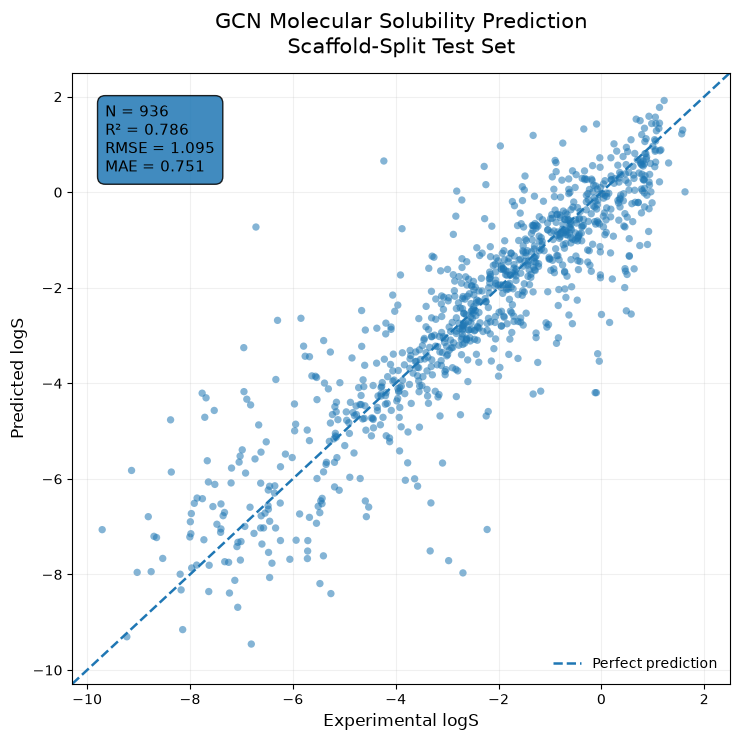


Saved figure:
/Users/maryta/Desktop/maryam_portfolio/images/gcn_scaffold_observed_vs_predicted.png


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. LOAD GCN SCAFFOLD TEST PREDICTIONS
# ============================================================

file_path = (
    Path.home()
    / "Downloads"
    / "mdm2_Reinvent_4_final"
    / "outputs"
    / "gnn_experiments"
    / "gcn_scaffold"
    / "test_predictions.csv"
)

df = pd.read_csv(file_path)

print("File:", file_path)
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))


# ============================================================
# 2. GET OBSERVED AND PREDICTED VALUES
# ============================================================

y_true = df["observed_logS"].values
y_pred = df["predicted_logS"].values


# ============================================================
# 3. CALCULATE METRICS DIRECTLY FROM PREDICTIONS
# ============================================================

residuals = y_pred - y_true

rmse = np.sqrt(np.mean(residuals ** 2))
mae = np.mean(np.abs(residuals))

ss_res = np.sum(residuals ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

r2 = 1 - ss_res / ss_tot

print("\nGCN Scaffold Test Metrics")
print("=" * 40)
print(f"N    = {len(df):,}")
print(f"R²   = {r2:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"MAE  = {mae:.4f}")


# ============================================================
# 4. CREATE OBSERVED VS PREDICTED PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(7.5, 7.5))

ax.scatter(
    y_true,
    y_pred,
    alpha=0.55,
    s=28,
    edgecolors="none"
)

# Common axis limits
minimum = min(y_true.min(), y_pred.min())
maximum = max(y_true.max(), y_pred.max())

padding = (maximum - minimum) * 0.05

minimum -= padding
maximum += padding

# Perfect prediction line
ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    "--",
    linewidth=1.8,
    label="Perfect prediction"
)

ax.set_xlim(minimum, maximum)
ax.set_ylim(minimum, maximum)

ax.set_xlabel(
    "Experimental logS",
    fontsize=12
)

ax.set_ylabel(
    "Predicted logS",
    fontsize=12
)

ax.set_title(
    "GCN Molecular Solubility Prediction\nScaffold-Split Test Set",
    fontsize=15,
    pad=14
)

# Metrics box
metric_text = (
    f"N = {len(df):,}\n"
    f"R² = {r2:.3f}\n"
    f"RMSE = {rmse:.3f}\n"
    f"MAE = {mae:.3f}"
)

ax.text(
    0.05,
    0.95,
    metric_text,
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.5",
        alpha=0.85
    )
)

ax.legend(
    loc="lower right",
    frameon=False
)

ax.grid(
    alpha=0.18
)

fig.tight_layout()


# ============================================================
# 5. SAVE HIGH-RESOLUTION FIGURE
# ============================================================

output_dir = (
    Path.home()
    / "Desktop"
    / "maryam_portfolio"
    / "images"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True
)

png_path = output_dir / "gcn_scaffold_observed_vs_predicted.png"

fig.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved figure:")
print(png_path)